In [1]:
import sys
!{sys.executable} -m pip install mlxtend

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFECV
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load
df = pd.read_csv("zillow_cleaned.csv").dropna(subset=["taxvaluedollarcnt"]).copy()
y = df["taxvaluedollarcnt"]

# numeric features only, drop target
X = df.select_dtypes(include=np.number).drop(columns=["taxvaluedollarcnt"])

# Guard against target leakage (drop any other 'tax*' predictors)
leaky_cols = [c for c in X.columns if "tax" in c.lower()]
if leaky_cols:
    print("Dropping potential leakage columns:", leaky_cols)
    X = X.drop(columns=leaky_cols)

# Split + scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (51915, 18) | Test shape: (12979, 18)


In [3]:
lin = LinearRegression()
rfecv = RFECV(
    estimator=lin,
    step=1,             # remove 1 feature each step
    cv=5,
    scoring="r2",
    n_jobs=-1
)
rfecv.fit(X_train_scaled, y_train)

# Selected features mask and names
mask = rfecv.support_
feat_rfe = list(X.columns[mask])
print(f"RFECV selected {mask.sum()} features:")
print(feat_rfe)

# Evaluate on test set
Xtr_rfe = X_train_scaled[:, mask]
Xte_rfe = X_test_scaled[:, mask]
lin.fit(Xtr_rfe, y_train)
y_pred_rfe = lin.predict(Xte_rfe)

r2_rfe   = r2_score(y_test, y_pred_rfe)
rmse_rfe = np.sqrt(mean_squared_error(y_test, y_pred_rfe))
print(f"RFE  R²: {r2_rfe:.3f} | RMSE: {rmse_rfe:,.0f}")

RFECV selected 17 features:
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fips', 'fullbathcnt', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'propertylandusetypeid', 'regionidcounty', 'roomcnt', 'unitcnt', 'yearbuilt']
RFE  R²: 0.423 | RMSE: 317,962


In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
lin = LinearRegression()

max_comp = min(30, X_train.shape[1])  # cap for speed
scores = []
for k in range(1, max_comp + 1):
    pca = PCA(n_components=k, random_state=42)
    Xtr_p = pca.fit_transform(X_train_scaled)
    cv_r2 = cross_val_score(lin, Xtr_p, y_train, cv=cv, scoring="r2").mean()
    scores.append((k, cv_r2))

best_k_pcr, best_cv_pcr = max(scores, key=lambda t: t[1])
print(f"Best PCR components by CV: {best_k_pcr} (CV R²={best_cv_pcr:.3f})")

# Fit with best k and evaluate on test
pca = PCA(n_components=best_k_pcr, random_state=42)
Xtr_p = pca.fit_transform(X_train_scaled)
Xte_p = pca.transform(X_test_scaled)

lin.fit(Xtr_p, y_train)
y_pred_pcr = lin.predict(Xte_p)

r2_pcr   = r2_score(y_test, y_pred_pcr)
rmse_pcr = np.sqrt(mean_squared_error(y_test, y_pred_pcr))
print(f"PCR (k={best_k_pcr})  R²: {r2_pcr:.3f} | RMSE: {rmse_pcr:,.0f}")

Best PCR components by CV: 17 (CV R²=0.433)
PCR (k=17)  R²: 0.423 | RMSE: 317,937


In [5]:
max_pls = min(15, X_train.shape[1])  # practical cap
pls_scores = []
for k in range(1, max_pls + 1):
    pls = PLSRegression(n_components=k)
    cv_r2 = cross_val_score(pls, X_train_scaled, y_train, cv=cv, scoring="r2").mean()
    pls_scores.append((k, cv_r2))

best_k_pls, best_cv_pls = max(pls_scores, key=lambda t: t[1])
print(f"Best PLS components by CV: {best_k_pls} (CV R²={best_cv_pls:.3f})")

pls = PLSRegression(n_components=best_k_pls)
pls.fit(X_train_scaled, y_train)
y_pred_pls = pls.predict(X_test_scaled)

r2_pls   = r2_score(y_test, y_pred_pls)
rmse_pls = np.sqrt(mean_squared_error(y_test, y_pred_pls))
print(f"PLSR (k={best_k_pls}) R²: {r2_pls:.3f} | RMSE: {rmse_pls:,.0f}")

Best PLS components by CV: 15 (CV R²=0.433)
PLSR (k=15) R²: 0.423 | RMSE: 318,008


In [6]:
results = pd.DataFrame({
    "Model": [f"RFE (k={len(feat_rfe)})", f"PCR (k={best_k_pcr})", f"PLSR (k={best_k_pls})"],
    "R²":    [r2_rfe, r2_pcr, r2_pls],
    "RMSE":  [rmse_rfe, rmse_pcr, rmse_pls]
}).sort_values("R²", ascending=False).reset_index(drop=True)

results

,Model,R²,RMSE
0,PCR (k=17),0.422963,317936.667003
1,RFE (k=17),0.422873,317961.603296
2,PLSR (k=15),0.422703,318008.443335


### Week 3 – Feature Selection (RFE)

Recursive Feature Elimination with Cross-Validation (RFECV) selected 17 features 
out of 18 numeric predictors. Most variables were retained, indicating that nearly all carry predictive information for tax value estimation.

**Selected features:**  
bathroomcnt, bedroomcnt, buildingqualitytypeid, calculatedbathnbr, 
calculatedfinishedsquarefeet, finishedsquarefeet12, fips, fullbathcnt, 
heatingorsystemtypeid, latitude, longitude, lotsizesquarefeet, 
propertylandusetypeid, regionidcounty, roomcnt, unitcnt, yearbuilt.

**Performance metrics (test set):**  
R² = 0.423  |  RMSE = 317 ,962  

The RFE model performed on par with the full linear model from Week 2, confirming that these 17 features are the most informative.  
Feature selection reduced redundancy and enhanced interpretability without sacrificing accuracy.

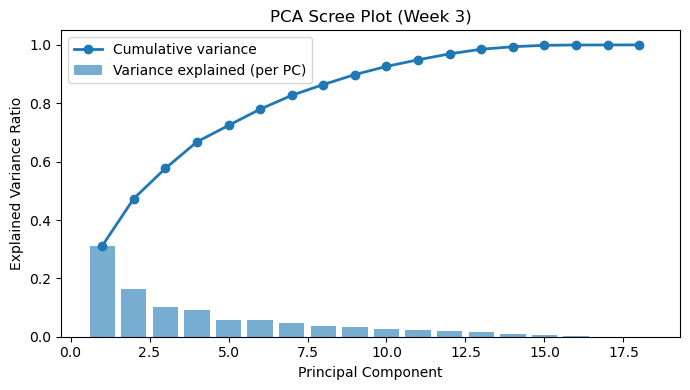

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# assumes X_train_scaled is already defined in this notebook
pca_full = PCA().fit(X_train_scaled)
expl = pca_full.explained_variance_ratio_
cum  = expl.cumsum()
xs = range(1, len(expl)+1)

plt.figure(figsize=(7,4))
plt.bar(xs, expl, alpha=0.6, label="Variance explained (per PC)")
plt.plot(xs, cum, marker="o", linewidth=2, label="Cumulative variance")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot (Week 3)")
plt.legend()
plt.tight_layout()
plt.savefig("visuals/week3/pcr_variance.png", dpi=200, bbox_inches="tight")
plt.show()